# Урок 15.20. Теория чисел: остатки, простые, генераторы

**Интерактивная версия:** `lessons/lesson_15_20/web/index.html`

Каждое утверждение урока проверяем кодом: арифметику — встроенными целыми Python, распределение простых —
решетом до 10⁶, числа в компьютере — numpy и `decimal`, влияние на модели — scikit-learn, XGBoost и LightGBM,
генератор курса — `gbcourse.rng`.

1. Делимость и деление с остатком: делители, фолды и батчи, системы счисления, признаки делимости.
2. НОД и алгоритм Евклида: шаги и худший случай, Безу, диофантовы уравнения и монеты, взаимная простота.
3. Простые числа: решето, разложение, числа Евклида, π(x) и Li(x), разрывы, гипотезы, гонка простых.
4. Сравнения по модулю: обратные, порядки, Ферма и Эйлер, быстрое возведение в степень, КТО, квадратичные вычеты.
5. Простота и криптография: Ферма и Миллер — Рабин, RSA, Диффи — Хеллман.
6. Числа в компьютере: переполнение, двоичные дроби, IEEE 754, ulp, порядок суммирования, float32 в деревьях.
7. Случайность и хеширование: ЛКГ и RANDU, Mulberry32, смещение по модулю, корзины, коллизии, стабильное разбиение,
   параллельные суммы.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
import struct
import zlib
from collections import Counter
from decimal import Decimal

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.tree import DecisionTreeRegressor

from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE

use_course_style()
MASK = 0xFFFFFFFF

## 1. Делимость и деление с остатком

Делители идут парами $d$ и $n/d$, поэтому проверяем $d \le \sqrt n$. Полные квадраты — единственные числа с
нечётным числом делителей (задача о шкафчиках).

In [2]:
def divisors(n):
    small = [d for d in range(1, math.isqrt(n) + 1) if n % d == 0]
    return sorted(set(small + [n // d for d in small]))


print("делители 12:", divisors(12), " 36:", divisors(36))
print("открытые шкафчики:", [i for i in range(1, 101) if len(divisors(i)) % 2])
print("совершенные числа до 10 000:", [n for n in range(2, 10_000) if sum(divisors(n)) - n == n])

делители 12: [1, 2, 3, 4, 6, 12]  36: [1, 2, 3, 4, 6, 9, 12, 18, 36]
открытые шкафчики: [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
совершенные числа до 10 000: [6, 28, 496, 8128]


Теорема о делении с остатком и два соглашения о частном: Python округляет вниз, C и JavaScript — к нулю.

In [3]:
print("divmod(100, 7) =", divmod(100, 7), " divmod(-7, 3) =", divmod(-7, 3), " math.fmod(-7, 3) =", math.fmod(-7, 3))
print("100 часов назад от 3:00 →", (3 - 100) % 24, "ч")
for n, k in ((23, 5), (1000, 7)):
    q, r = divmod(n, k)
    sk = [len(t) for _, t in KFold(k).split(np.zeros(n))]
    assert sk == [q + 1] * r + [q] * (k - r)
    print(f"{n} = {q}·{k} + {r}: KFold {sk}")
y = np.array([0] * 77 + [1] * 23)
print("StratifiedKFold, положительных в фолдах:", [int(y[t].sum()) for _, t in StratifiedKFold(5).split(np.zeros(100), y)])
print("шагов за эпоху, n = 1000, b = 64:", (1000 + 64 - 1) // 64, "; последний батч:", 1000 % 64)

divmod(100, 7) = (14, 2)  divmod(-7, 3) = (-3, 2)  math.fmod(-7, 3) = -1.0
100 часов назад от 3:00 → 23 ч
23 = 4·5 + 3: KFold [5, 5, 5, 4, 4]
1000 = 142·7 + 6: KFold [143, 143, 143, 143, 143, 143, 142]
StratifiedKFold, положительных в фолдах: [4, 4, 5, 5, 5]
шагов за эпоху, n = 1000, b = 64: 16 ; последний батч: 40


Системы счисления: цифры — остатки повторного деления; признаки делимости — веса $10^k \bmod d$.

In [4]:
def to_base(n, b):
    digits = []
    while n:
        n, r = divmod(n, b)
        digits.append("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"[r])
    return "".join(reversed(digits)) or "0"


print("13 =", to_base(13, 2), "₂;  2026 =", to_base(2026, 16), "₁₆ =", to_base(2026, 8), "₈;  бит у 10⁶:", (10**6).bit_length())
for d in (3, 7, 9, 11, 13):
    w = [pow(10, k, d) for k in range(8)]
    print(f"веса 10^k mod {d:2}: {w}")
print("918082 mod 11 =", 918082 % 11, " 1234567 mod 7 =", 1234567 % 7, "≡", (1 - 234 + 567) % 1001 % 7)

13 = 1101 ₂;  2026 = 7EA ₁₆ = 3752 ₈;  бит у 10⁶: 20
веса 10^k mod  3: [1, 1, 1, 1, 1, 1, 1, 1]
веса 10^k mod  7: [1, 3, 2, 6, 4, 5, 1, 3]
веса 10^k mod  9: [1, 1, 1, 1, 1, 1, 1, 1]
веса 10^k mod 11: [1, 10, 1, 10, 1, 10, 1, 10]
веса 10^k mod 13: [1, 10, 9, 12, 3, 4, 1, 10]
918082 mod 11 = 0  1234567 mod 7 = 5 ≡ 5


## 2. НОД, алгоритм Евклида, Безу

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


НОД(12, 18) = 6  НОК = 36  НОК(1..10) = 2520
шагов: (252, 198) → 4 ; (89, 55) → 9
максимум шагов до 100: 10 в среднем: 3.983
Безу: (18, 4, -5)  3⁻¹ mod 7 = 5  17⁻¹ mod 3120 = 2753


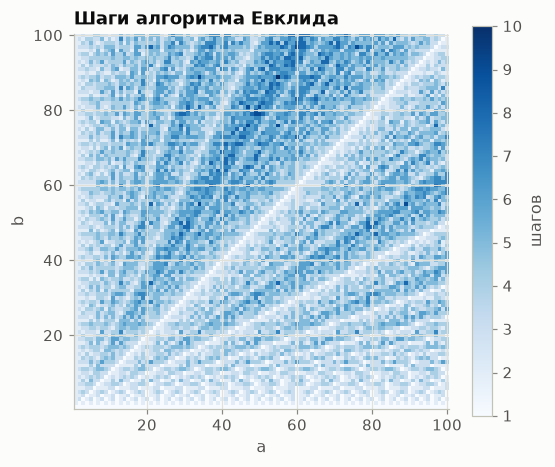

In [5]:
def euclid_steps(a, b):
    k = 0
    while b:
        a, b, k = b, a % b, k + 1
    return k


def ext_gcd(a, b):
    r0, r1, x0, x1, y0, y1 = a, b, 1, 0, 0, 1
    while r1:
        q = r0 // r1
        r0, r1, x0, x1, y0, y1 = r1, r0 - q * r1, x1, x0 - q * x1, y1, y0 - q * y1
    return r0, x0, y0


print("НОД(12, 18) =", math.gcd(12, 18), " НОК =", math.lcm(12, 18), " НОК(1..10) =", math.lcm(*range(1, 11)))
print("шагов: (252, 198) →", euclid_steps(252, 198), "; (89, 55) →", euclid_steps(89, 55))
S = np.array([[euclid_steps(a, b) for a in range(1, 101)] for b in range(1, 101)])
print("максимум шагов до 100:", S.max(), "в среднем:", round(S.mean(), 3))
print("Безу:", ext_gcd(252, 198), " 3⁻¹ mod 7 =", pow(3, -1, 7), " 17⁻¹ mod 3120 =", pow(17, -1, 3120))

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(S, origin="lower", extent=(0.5, 100.5, 0.5, 100.5), cmap="Blues")
fig.colorbar(im, ax=ax, label="шагов")
ax.set(title="Шаги алгоритма Евклида", xlabel="a", ylabel="b")
plt.show()

Линейные диофантовы уравнения и задача о монетах; число Фробениуса $ab - a - b$.

In [6]:
print("3x + 5y = 22, x, y ≥ 0:", [(x, (22 - 3 * x) // 5) for x in range(8) if (22 - 3 * x) % 5 == 0])


def nonrep(coins, limit=300):
    ok = [True] + [False] * limit
    for v in range(1, limit + 1):
        ok[v] = any(v >= c and ok[v - c] for c in coins)
    return [v for v in range(limit + 1) if not ok[v]]


for coins in ([3, 5], [5, 8], [6, 9, 20]):
    bad = nonrep(coins)
    print(f"монеты {coins}: Фробениус {max(bad)}, ненабираемых {len(bad)}")

3x + 5y = 22, x, y ≥ 0: [(4, 2)]
монеты [3, 5]: Фробениус 7, ненабираемых 4
монеты [5, 8]: Фробениус 27, ненабираемых 14
монеты [6, 9, 20]: Фробениус 43, ненабираемых 22


Взаимная простота: доля пар с НОД = 1 стремится к $6/\pi^2$.

In [7]:
for N in (10, 100, 1000):
    a = np.arange(1, N + 1)
    print(f"N = {N:4}: доля {float((np.gcd.outer(a, a) == 1).mean()):.6f}")
print("6/π² =", 6 / math.pi**2)

N =   10: доля 0.630000
N =  100: доля 0.608700
N = 1000: доля 0.608383
6/π² = 0.6079271018540267


## 3. Простые числа

In [8]:
N = 10**6
is_p = np.ones(N + 1, bool)
is_p[:2] = False
for p in range(2, math.isqrt(N) + 1):
    if is_p[p]:
        is_p[p * p :: p] = False
primes = np.nonzero(is_p)[0]
pi = np.cumsum(is_p)


def factorize(n):
    out, p = {}, 2
    while p * p <= n:
        while n % p == 0:
            out[p] = out.get(p, 0) + 1
            n //= p
        p += 1
    if n > 1:
        out[n] = out.get(n, 0) + 1
    return out


def li(x):
    L, term, s = math.log(x), 1.0, 0.0
    for k in range(1, 200):
        term *= L / k
        s += term / k
    return 0.5772156649015329 + math.log(L) + s


print("360 =", factorize(360), " τ =", math.prod(e + 1 for e in factorize(360).values()))
prod = 1
for p in primes[:6]:
    prod *= int(p)
    print(f"числа Евклида: {prod} + 1 = {prod + 1} = {factorize(prod + 1)}")
for x in (100, 1000, 10**4, 10**5, 10**6):
    print(f"π({x}) = {pi[x]}, x/ln x = {x / math.log(x):.0f}, Li(x) = {li(x) - li(2):.0f}")
gaps = np.diff(primes)
print("наибольший разрыв до 10⁶:", gaps.max(), "после", primes[gaps.argmax()])
print("n² + n + 41 простое для", sum(is_p[n * n + n + 41] for n in range(100)), "из 100 n; первое составное при n =", next(n for n in range(100) if not is_p[n * n + n + 41]))

360 = {2: 3, 3: 2, 5: 1}  τ = 24
числа Евклида: 2 + 1 = 3 = {3: 1}
числа Евклида: 6 + 1 = 7 = {7: 1}
числа Евклида: 30 + 1 = 31 = {31: 1}
числа Евклида: 210 + 1 = 211 = {211: 1}
числа Евклида: 2310 + 1 = 2311 = {2311: 1}
числа Евклида: 30030 + 1 = 30031 = {59: 1, 509: 1}
π(100) = 25, x/ln x = 22, Li(x) = 29
π(1000) = 168, x/ln x = 145, Li(x) = 177
π(10000) = 1229, x/ln x = 1086, Li(x) = 1245
π(100000) = 9592, x/ln x = 8686, Li(x) = 9629
π(1000000) = 78498, x/ln x = 72382, Li(x) = 78627


наибольший разрыв до 10⁶: 114 после 492113
n² + n + 41 простое для 86 из 100 n; первое составное при n = 40


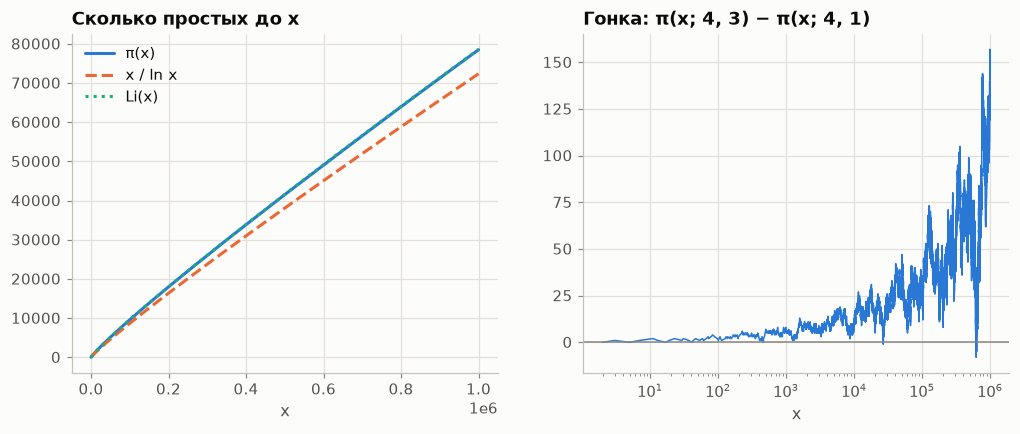

класс 4k + 1 впервые впереди при p = 26861 ; до 10⁶: 39175 : 39322


In [9]:
xs = np.linspace(100, N, 400).astype(int)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(xs, pi[xs], color=BLUE, label="π(x)")
a1.plot(xs, xs / np.log(xs), color=ORANGE, ls="--", label="x / ln x")
a1.plot(xs, [li(x) - li(2) for x in xs], color=AQUA, ls=":", label="Li(x)")
a1.set(title="Сколько простых до x", xlabel="x")
a1.legend()
c1 = np.cumsum(primes % 4 == 1)
c3 = np.cumsum(primes % 4 == 3)
a2.plot(primes, c3 - c1, color=BLUE, lw=1)
a2.axhline(0, color=MUTED, lw=1)
a2.set_xscale("log")
a2.set(title="Гонка: π(x; 4, 3) − π(x; 4, 1)", xlabel="x")
plt.show()
print("класс 4k + 1 впервые впереди при p =", primes[np.argmax(c1 > c3)], "; до 10⁶:", int(c1[-1]), ":", int(c3[-1]))

Гипотезы: Гольдбах, близнецы, Коллатц (проверка — не доказательство).

In [10]:
def goldbach(n):
    return [(p, n - p) for p in range(2, n // 2 + 1) if is_p[p] and is_p[n - p]]


def collatz(n):
    k, m = 0, n
    while n != 1:
        n = 3 * n + 1 if n % 2 else n // 2
        k, m = k + 1, max(m, n)
    return k, m


print("100:", goldbach(100), "; у 1000 разложений:", len(goldbach(1000)))
print("пар близнецов до 1000:", sum(1 for p in primes[primes < 999] if is_p[p + 2]), "; до 10⁶:", int(np.sum(is_p[3 : N - 1] & is_p[5 : N + 1])))
print("Коллатц: 27 →", collatz(27), "; дольше всех до 1000:", max((collatz(n)[0], n) for n in range(1, 1000)))
print("2¹¹ − 1 =", factorize(2**11 - 1), "; 2³² + 1 =", factorize(2**32 + 1))

100: [(3, 97), (11, 89), (17, 83), (29, 71), (41, 59), (47, 53)] ; у 1000 разложений: 28
пар близнецов до 1000: 35 ; до 10⁶: 8169
Коллатц: 27 → (111, 9232) ; дольше всех до 1000: (178, 871)
2¹¹ − 1 = {23: 1, 89: 1} ; 2³² + 1 = {641: 1, 6700417: 1}


## 4. Сравнения по модулю

In [11]:
def order(a, m):
    k, x = 1, a % m
    while x != 1:
        x, k = x * a % m, k + 1
    return k


def phi(n):
    r = n
    for p in factorize(n):
        r -= r // p
    return r


print("6x ≡ 4 (mod 10):", [x for x in range(10) if (6 * x - 4) % 10 == 0], "; 6x ≡ 5:", [x for x in range(10) if (6 * x - 5) % 10 == 0])
print("степени 7 mod 10:", [pow(7, k, 10) for k in range(1, 6)], "→ последняя цифра 7²⁰²⁶ =", pow(7, 2026, 10))
print("ord₁₁(2) =", order(2, 11), " ord₁₁(3) =", order(3, 11), " первообразные корни mod 11:", [a for a in range(1, 11) if order(a, 11) == 10])
print("степени 2 mod 12:", [pow(2, k, 12) for k in range(8)], "— в 1 не возвращаются")
print("Ферма: 2¹⁰ mod 11 =", pow(2, 10, 11), "; Эйлер: φ(12) =", phi(12), ", 5⁴ mod 12 =", pow(5, 4, 12), "; Вильсон: 12! mod 13 =", math.factorial(12) % 13)
print("φ(36) =", phi(36), "= φ(4)·φ(9) =", phi(4) * phi(9), "; Σ φ(d) по d | 36 =", sum(phi(d) for d in divisors(36)))

6x ≡ 4 (mod 10): [4, 9] ; 6x ≡ 5: []
степени 7 mod 10: [7, 9, 3, 1, 7] → последняя цифра 7²⁰²⁶ = 9
ord₁₁(2) = 10  ord₁₁(3) = 5  первообразные корни mod 11: [2, 6, 7, 8]
степени 2 mod 12: [1, 2, 4, 8, 4, 8, 4, 8] — в 1 не возвращаются
Ферма: 2¹⁰ mod 11 = 1 ; Эйлер: φ(12) = 4 , 5⁴ mod 12 = 1 ; Вильсон: 12! mod 13 = 12
φ(36) = 12 = φ(4)·φ(9) = 12 ; Σ φ(d) по d | 36 = 36


In [12]:
def fast_pow(a, e, m):
    r, mults = 1, 0
    for i, bit in enumerate(bin(e)[2:]):
        if i:
            r, mults = r * r % m, mults + 1
        if bit == "1":
            r, mults = r * a % m, mults + (i > 0)
    return r, mults


def fib_mod(n, m):
    def mul(A, B):
        return [[(A[0][0] * B[0][0] + A[0][1] * B[1][0]) % m, (A[0][0] * B[0][1] + A[0][1] * B[1][1]) % m],
                [(A[1][0] * B[0][0] + A[1][1] * B[1][0]) % m, (A[1][0] * B[0][1] + A[1][1] * B[1][1]) % m]]
    R, A = [[1, 0], [0, 1]], [[1, 1], [1, 0]]
    while n:
        if n & 1:
            R = mul(R, A)
        A, n = mul(A, A), n >> 1
    return R[0][1]


print("3¹⁰⁰ mod 7 =", fast_pow(3, 100, 7), "(значение, умножений); 3¹³ =", fast_pow(3, 13, 10**9))
print("F(10¹⁸) mod (10⁹ + 7) =", fib_mod(10**18, 10**9 + 7))


def crt(r1, m1, r2, m2):
    return (r1 * m2 * pow(m2, -1, m1) + r2 * m1 * pow(m1, -1, m2)) % (m1 * m2)


print("КТО: x ≡ 2 (3), 3 (5) →", crt(2, 3, 3, 5), "; задача Сунь-цзы →", crt(crt(2, 3, 3, 5), 15, 2, 7))
print("пар остатков (mod 4, mod 6) среди 0…23:", len({(k % 4, k % 6) for k in range(24)}))
for m in (4, 8, 10, 13):
    print(f"квадраты mod {m}: {sorted({x * x % m for x in range(m)})}")
two_sq = lambda n: next(((a, math.isqrt(n - a * a)) for a in range(math.isqrt(n) + 1) if math.isqrt(n - a * a) ** 2 == n - a * a), None)  # noqa: E731
print("простые как суммы двух квадратов:", {int(p): two_sq(int(p)) for p in primes[:12]})

3¹⁰⁰ mod 7 = (4, 8) (значение, умножений); 3¹³ = (1594323, 5)
F(10¹⁸) mod (10⁹ + 7) = 209783453
КТО: x ≡ 2 (3), 3 (5) → 8 ; задача Сунь-цзы → 23
пар остатков (mod 4, mod 6) среди 0…23: 12
квадраты mod 4: [0, 1]
квадраты mod 8: [0, 1, 4]
квадраты mod 10: [0, 1, 4, 5, 6, 9]
квадраты mod 13: [0, 1, 3, 4, 9, 10, 12]
простые как суммы двух квадратов: {2: (1, 1), 3: None, 5: (1, 2), 7: None, 11: None, 13: (2, 3), 17: (1, 4), 19: None, 23: None, 29: (2, 5), 31: None, 37: (1, 6)}


## 5. Простота и криптография

In [13]:
def strong_liar(a, n):
    d, s = n - 1, 0
    while d % 2 == 0:
        d, s = d // 2, s + 1
    x = pow(a, d, n)
    if x in (1, n - 1):
        return True
    for _ in range(s - 1):
        x = x * x % n
        if x == n - 1:
            return True
    return False


print("2³⁴⁰ mod 341 =", pow(2, 340, 341), " 3³⁴⁰ mod 341 =", pow(3, 340, 341))
for n in (341, 561, 1105, 1729, 2047):
    fl = sum(pow(a, n - 1, n) == 1 for a in range(2, n - 1))
    sl = sum(strong_liar(a, n) for a in range(2, n - 1))
    print(f"n = {n}: лжецов Ферма {fl}, сильных лжецов {sl} из {n - 3}")
p, q, e = 61, 53, 17
n, ph = p * q, (p - 1) * (q - 1)
d = pow(e, -1, ph)
print(f"RSA: n = {n}, φ = {ph}, d = {d}; 65 → {pow(65, e, n)} → {pow(pow(65, e, n), d, n)}")
A, B = pow(5, 6, 23), pow(5, 15, 23)
print(f"Диффи — Хеллман: A = {A}, B = {B}, ключи {pow(B, 6, 23)} и {pow(A, 15, 23)}")

2³⁴⁰ mod 341 = 1  3³⁴⁰ mod 341 = 56
n = 341: лжецов Ферма 98, сильных лжецов 48 из 338
n = 561: лжецов Ферма 318, сильных лжецов 8 из 558
n = 1105: лжецов Ферма 766, сильных лжецов 28 из 1102
n = 1729: лжецов Ферма 1294, сильных лжецов 160 из 1726
n = 2047: лжецов Ферма 482, сильных лжецов 240 из 2044
RSA: n = 3233, φ = 3120, d = 2753; 65 → 2790 → 65
Диффи — Хеллман: A = 8, B = 19, ключи 2 и 2


## 6. Числа в компьютере

In [14]:
print("uint8 200 + 100 =", np.array([200], np.uint8) + np.uint8(100), "; int32 50000² =", np.array([50000], np.int32) ** 2, "; int8 −5 →", f"{np.int8(-5).view(np.uint8):08b}")
print("0.1 хранится как", Decimal(0.1))
print("float32(0.1) =", Decimal(float(np.float32(0.1))), "; float32(16777217) =", float(np.float32(16777217)))
print("биты 1.0:", hex(struct.unpack(">Q", struct.pack(">d", 1.0))[0]), "; ε =", np.finfo(float).eps, "; ε float32 =", np.finfo(np.float32).eps)
T = 1_760_000_000
print("шаг float32 у unix-времени:", np.spacing(np.float32(T)), "с; 60 минутных событий → различных float32:", np.unique((T + 60 * np.arange(60)).astype(np.float32)).size)


def period_digits(p, q, b):
    r, seen, k = p % q, {}, 0
    while r and r not in seen:
        seen[r], r, k = k, r * b % q, k + 1
    return (k, 0) if not r else (seen[r], k - seen[r])


print("(предпериод, период): 1/7 →", period_digits(1, 7, 10), "; 1/97 →", period_digits(1, 97, 10), "; 0.1 в двоичной →", period_digits(1, 10, 2))

uint8 200 + 100 = [44] ; int32 50000² = [-1794967296] ; int8 −5 → 11111011
0.1 хранится как 0.1000000000000000055511151231257827021181583404541015625
float32(0.1) = 0.100000001490116119384765625 ; float32(16777217) = 16777216.0
биты 1.0: 0x3ff0000000000000 ; ε = 2.220446049250313e-16 ; ε float32 = 1.1920929e-07
шаг float32 у unix-времени: 128.0 с; 60 минутных событий → различных float32: 29
(предпериод, период): 1/7 → (0, 6) ; 1/97 → (0, 96) ; 0.1 в двоичной → (1, 4)


In [15]:
def seq(a):
    s = 0.0
    for x in a:
        s += x
    return s


def kahan(a):
    s = c = 0.0
    for x in a:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


print("(0.1 + 0.2) + 0.3 =", (0.1 + 0.2) + 0.3, "; 0.1 + (0.2 + 0.3) =", 0.1 + (0.2 + 0.3))
print("цикл 10×0.1 =", seq([0.1] * 10), "; sum =", sum([0.1] * 10), "; fsum =", math.fsum([0.1] * 10))
big = [1e16] + [1.0] * 10 + [-1e16]
print("10¹⁶ + десять единиц − 10¹⁶: цикл", seq(big), ", Кэхэн", kahan(big), ", fsum", math.fsum(big))
x3 = np.array([1e9, 1e9 + 1, 1e9 + 2])
print("дисперсия «в лоб»:", np.mean(x3**2) - np.mean(x3) ** 2, "; np.var:", np.var(x3))
rng = Mulberry32(7)
u = [rng.random() for _ in range(10**6)]
print("сумма 10⁶ значений random() курса совпадает с точной:", seq(u) == math.fsum(u))

(0.1 + 0.2) + 0.3 = 0.6000000000000001 ; 0.1 + (0.2 + 0.3) = 0.6
цикл 10×0.1 = 0.9999999999999999 ; sum = 1.0 ; fsum = 1.0
10¹⁶ + десять единиц − 10¹⁶: цикл 0.0 , Кэхэн 10.0 , fsum 10.0
дисперсия «в лоб»: 0.0 ; np.var: 0.6666666666666666


сумма 10⁶ значений random() курса совпадает с точной: True


float32 в деревьях: события раз в минуту при unix-времени склеиваются по 128 секунд. Граница меток между 29:00 и
30:00 попадает внутрь «склейки» — XGBoost и scikit-learn её не находят, LightGBM (пороги в double) находит.

In [16]:
X = (T + 60 * np.arange(60)).astype(np.float64).reshape(-1, 1)
y = (np.arange(60) >= 30).astype(float)
for name, Z in (("как есть", X), ("x − x₀", X - T)):
    tr = DecisionTreeRegressor(max_depth=1).fit(Z, y)
    xg = xgb.XGBRegressor(n_estimators=1, max_depth=1, learning_rate=1.0, base_score=0.5, reg_lambda=0, min_child_weight=0).fit(Z, y)
    lg = lgb.LGBMRegressor(n_estimators=1, num_leaves=2, learning_rate=1.0, min_child_samples=1, min_data_in_bin=1, verbose=-1).fit(Z, y)
    errs = [float(np.abs(m.predict(Z) - y).max()) for m in (tr, xg, lg)]
    print(f"{name:9}: ошибка sklearn {errs[0]:.3f}, XGBoost {errs[1]:.3f}, LightGBM {errs[2]:.3f}")
print("порог XGBoost:", xgb.XGBRegressor(n_estimators=1, max_depth=1).fit(X, y).get_booster().get_dump()[0].split("\n")[0])

как есть : ошибка sklearn 0.968, XGBoost 0.968, LightGBM 0.000
x − x₀   : ошибка sklearn 0.000, XGBoost 0.000, LightGBM 0.000
порог XGBoost: 0:[f0<1.76000179e+09] yes=1,no=2,missing=2


## 7. Случайность, хеширование, воспроизводимость

In [17]:
def lcg_period(a, c, m, x0=0):
    seen, x = {}, x0 % m
    while x not in seen:
        seen[x] = len(seen)
        x = (a * x + c) % m
    return len(seen) - seen[x]


print("периоды ЛКГ m = 16: (5, 3) →", lcg_period(5, 3, 16, 1), ", (3, 3) →", lcg_period(3, 3, 16, 1), ", (5, 4) →", lcg_period(5, 4, 16, 1), "; Лемер 3 mod 31 →", lcg_period(3, 0, 31, 1))
print("пар (a, c) с полным периодом при m = 64:", sum(lcg_period(a, c, 64) == 64 for a in range(64) for c in range(64)))
m, a = 2**31, 65539
v, vals = 1, []
for _ in range(3002):
    v = a * v % m
    vals.append(v)
vals = np.array(vals, dtype=np.int64)
k = 9 * vals[:-2] - 6 * vals[1:-1] + vals[2:]
print("RANDU: a² mod 2³¹ = 6a − 9:", a * a % m == 6 * a - 9, "; плоскостей у 3000 троек:", np.unique(k // m).size)

периоды ЛКГ m = 16: (5, 3) → 16 , (3, 3) → 8 , (5, 4) → 2 ; Лемер 3 mod 31 → 30
пар (a, c) с полным периодом при m = 64: 512
RANDU: a² mod 2³¹ = 6a − 9: True ; плоскостей у 3000 троек: 15


In [18]:
def mulberry32(state):
    state = (state + 0x6D2B79F5) & MASK
    t = ((state ^ (state >> 15)) * (1 | state)) & MASK
    t = ((t + (((t ^ (t >> 7)) * (61 | t)) & MASK)) & MASK) ^ t
    return state, (t ^ (t >> 14)) & MASK


st, mine = 42, []
for _ in range(3):
    st, out = mulberry32(st)
    mine.append(round(out / 2**32, 6))
ref = Mulberry32(42)
print("вручную:", mine, " gbcourse:", [round(ref.random(), 6) for _ in range(3)])

r = Mulberry32(3)
flips = []
for _ in range(2000):
    s0 = r.next_uint32()
    o0 = mulberry32((s0 - 0x6D2B79F5) & MASK)[1]
    flips.append(np.mean([bin(o0 ^ mulberry32(((s0 ^ (1 << b)) - 0x6D2B79F5) & MASK)[1]).count("1") for b in range(32)]))
print("лавина: в среднем меняется", round(float(np.mean(flips)), 2), "бит из 32")
print("смещение 4 бита → 3 исхода:", sorted(Counter(u % 3 for u in range(16)).items()), "; 2³² = 3·", 2**32 // 3, "+", 2**32 % 3)

вручную: [0.601104, 0.448291, 0.852466]  gbcourse: [0.601104, 0.448291, 0.852466]
лавина: в среднем меняется 15.98 бит из 32
смещение 4 бита → 3 исхода: [(0, 6), (1, 5), (2, 5)] ; 2³² = 3· 1431655765 + 1


In [19]:
ids = [10 * i for i in range(200)]
print("корзин, шаг 10: m = 100 →", len({i % 100 for i in ids}), "; m = 97 →", len({i % 97 for i in ids}))
ids64 = [64 * i for i in range(200)]
print("кратные 64, m = 128: id % m →", len({i % 128 for i in ids64}), "; мультипликативный хеш →", len({((i * 0x9E3779B9) & MASK) * 128 >> 32 for i in ids64}))
mb, nb = 2**20, 10**5
print("FeatureHasher 2²⁰ и 10⁵ категорий: занято ≈", round(mb * (1 - (1 - 1 / mb) ** nb)), "; доля с соседом ≈", round(1 - (1 - 1 / mb) ** (nb - 1), 4))
p_none = math.prod(1 - i / 365 for i in range(23))
print("23 человека: P(совпадение) =", round(1 - p_none, 4), "; 50 % для 32-бит хеша при n ≈", round(math.sqrt(2 * math.log(2) * 2**32)))
print("crc32('user_42') % 100 =", zlib.crc32(b"user_42") % 100, "; доля теста:", sum(zlib.crc32(f"user_{u}".encode()) % 100 < 20 for u in range(10_000)) / 10_000)

корзин, шаг 10: m = 100 → 10 ; m = 97 → 97
кратные 64, m = 128: id % m → 2 ; мультипликативный хеш → 121
FeatureHasher 2²⁰ и 10⁵ категорий: занято ≈ 95380 ; доля с соседом ≈ 0.091
23 человека: P(совпадение) = 0.5073 ; 50 % для 32-бит хеша при n ≈ 77163
crc32('user_42') % 100 = 13 ; доля теста: 0.2023


Параллельные суммы: одни и те же градиенты, разбитые на $T$ кусков, дают разные последние биты, а «равные»
разбиения A и B (одни объекты слева, разный порядок обхода) меняют победителя вместе с $T$.

In [20]:
rng = Mulberry32(3)
g = [(math.floor(rng.random() * 2_000_000) - 1_000_000) / 3_000 for _ in range(2000)]


def chunked(xs, T):
    L = len(xs)
    parts = [seq(xs[t * L // T : (t + 1) * L // T]) for t in range(T)]
    return seq(parts)


ref = chunked(g, 1)
dev = [round((chunked(g, T) - ref) / math.ulp(ref)) for T in range(1, 17)]
print("отклонение от T = 1, ulp:", dev, "; различных:", len(set(dev)))
L1 = g[:1000]
L2 = L1[::-1]
print("победитель A/B по T:", "".join("A" if chunked(L1, T) ** 2 > chunked(L2, T) ** 2 else "B" if chunked(L1, T) ** 2 < chunked(L2, T) ** 2 else "=" for T in range(1, 17)))

отклонение от T = 1, ulp: [0, -6, -7, -2, 1, -12, -3, -7, -5, 9, -1, 2, -1, -2, -2, 3] ; различных: 12
победитель A/B по T: AABAAAABBAAAABBA


## Упражнения

Задания — в `exercises/tasks.md`, решения — в `exercises/solutions.py`. Попробуйте сначала сами:

1. Размеры фолдов и батчей через `divmod`; при каких k все фолды равны.
2. Универсальный признак делимости через веса $10^k \bmod d$.
3. Расширенный алгоритм Евклида и обратные по модулям 12 и 13.
4. Формулы Сильвестра для монет.
5. Оценка доли взаимно простых пар Монте-Карло.
6. Наибольший разрыв между простыми до 10⁶.
7. Последние две цифры $7^{2026}$ через порядок.
8. Китайская теорема для четырёх модулей.
9. Доля сильных лжецов Миллера — Рабина; числа Кармайкла.
10. Ошибка разных способов суммирования.
11. При каком шаге события перестают склеиваться во float32.
12. Халл — Добелл для m = 256, младшие биты ЛКГ, хеширование кратных 24.